# *Aufgabe: kNN und Data Preprocessing*

### Aufgabe 1. kNN

Nutzen Sie kNN von scikit-learn (KNeighborsRegressor), um damit den Benzinverbrauch eines Fahrzeugs auf Grundlage seiner Eigenschaften (Gewicht, PS, ...) vorherzusagen. Nutzen Sie dafür den bereitgestellten Miles-per-Gallon Datensatz mpg.csv.

Messen Sie die Leistungsfähigkeit Ihres Modells mit einer passenden Metrik. Plotten Sie die Akkuranz in Abhängigkeit von k nearest Neighbours.

0. Imports

In [ ]:
import pandas as pd
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error as mse
import matplotlib.pyplot as plt
import os

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score
import math

1. Lesen von Data und Train/Test split

In [71]:
path = os.path.join("..", "..", "..", "data", "mpg.csv")
mpg = pd.read_csv(path)
X_train, X_test, y_train, y_test = train_test_split(mpg.drop(columns=["mpg"],axis=1), mpg["mpg"], test_size=0.2)
mpg.head()
#mpg.info()
mpg.describe()
#print(train.shape)
#print(test.shape)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.178894,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.347728,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,92.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,125.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


Trainieren des Modells für mehrere k-Werte:

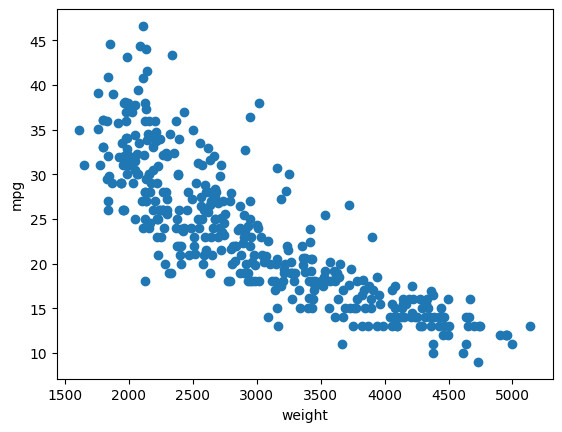

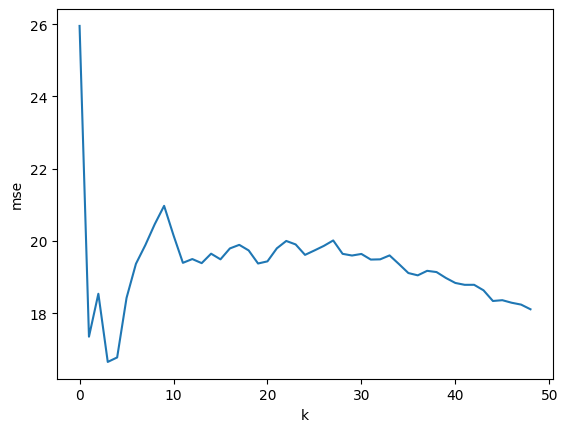

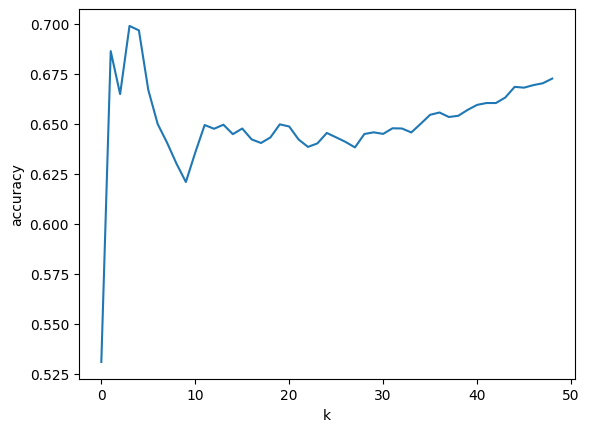

In [ ]:
error = []
accuracy = []
# Probiere mögliche Anzahl Nachbarn durch
X= mpg.drop(columns=["mpg","cylinders","displacement","horsepower","acceleration","model year","origin"])
y = mpg["mpg"]

plt.scatter(X, y)
plt.xlabel("weight")
plt.ylabel("mpg")
plt.show()
for k in range(1, 50):
    # Trainiere und evaluiere das Modell, speicher den Fehler zur Darstellung später
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    knn.score(X_train, y_train) # nicht auf test-Daten machen, wenn man Entscheidungen treffen will, die trifft man NUR auf den Trainingsdaten (man kann davon einen Validierungsteil abzweigen)
    error.append(mse(y_test, y_pred))
    accuracy.append(knn.score(X_test, y_test))

# plot(error)
plt.plot(error)
plt.xlabel("k")
plt.ylabel("mse")
plt.show()

#plot accuracy
plt.plot(accuracy)
plt.xlabel("k")
plt.ylabel("accuracy")
plt.show()

c:\Code-Projekte\FullStackMachineLearning\full-stack-machine-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


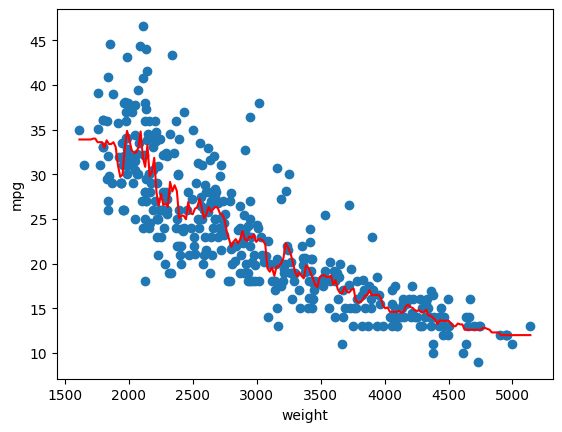

In [78]:

X_plot = mpg[["weight"]]
y = mpg["mpg"]

knn_plot = KNeighborsRegressor(n_neighbors=10)
knn_plot.fit(X_plot, y)

plt.scatter(X_plot, y)
x_range = np.linspace(X_plot.min(), X_plot.max(), 200).reshape(-1, 1)
y_pred = knn_plot.predict(x_range)

plt.plot(x_range, y_pred, color="red")
plt.xlabel("weight")
plt.ylabel("mpg")
plt.show()


### Aufgabe 2. Preprocessing

In [79]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from tqdm.notebook import trange
from sklearn.metrics import accuracy_score

Daten einlesen

In [80]:
path = os.path.join("..", "..", "..", "data", "census.csv")
census = pd.read_csv(path)
census = census.drop(["capital-gain", "capital-loss"], axis=1)
census.head()
#census.info()



,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,target
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K


Imputing fehlender Werte:

In [95]:
# Nachsehen ob echte NaN-Wert in den Spalten existieren
census.isnull().sum()
df = pd.read_csv(path)
# Untersuche weitere mögliche fehlende Werte
cat_cols = df.select_dtypes(include=["object", "category"]).columns
# Übersicht erstellen, welche Werte in den kategorischen Spalten existieren
overview = {col: df[col].dropna().unique().tolist() for col in cat_cols}

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())

# es könnten auch '-', '?', '/' oder ähnliches in den Daten sein, wenn diese aus anderen Datenformaten stammen



=== workclass ===
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

=== education ===
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

=== marital-status ===
marital-status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

=== occupation ===
oc

In [105]:
# Benutze einen Imputer oder ersetzen Sie die Werte per Hand
# Strategien könnten häufigste Werte oder der Mittelwert sein
# # Durch Spalten gehen und Leerzeichen vor dem Wert entfernen
df = df.apply(lambda col: col.str.strip() if col.dtype == "object" else col)
# ? durch häufigsten Wert ersetzen
#df["occupation"] = df["occupation"].replace("?", "Prof-specialty")
#df["occupation"].unique()
df["native-country"] = df["native-country"].replace("?", "United-States")
df["native-country"].unique()
#df["workclass"] = df["workclass"].replace("?", "Private")
#df["workclass"].unique()



# Imputer
df["workclass"] = df["workclass"].replace("?", None)
imputer = SimpleImputer(strategy="most_frequent")
df["workclass"] = imputer.fit_transform(df[["workclass"]]).ravel()
df["workclass"].unique()

#Zeilen entfernen
df = df[df["occupation"] != "?"]
df["occupation"].unique()

for col in cat_cols:
    print(f"\n=== {col} ===")
    print(df[col].value_counts())



=== workclass ===
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Name: count, dtype: int64

=== education ===
education
HS-grad         9968
Some-college    6775
Bachelors       5182
Masters         1675
Assoc-voc       1321
11th            1056
Assoc-acdm      1020
10th             831
7th-8th          573
Prof-school      558
9th              463
Doctorate        398
12th             393
5th-6th          303
1st-4th          156
Preschool         46
Name: count, dtype: int64

=== marital-status ===
marital-status
Married-civ-spouse       14339
Never-married             9912
Divorced                  4258
Separated                  959
Widowed                    840
Married-spouse-absent      389
Married-AF-spouse           21
Name: count, dtype: int64

=== occupation ===
occupation
Prof-specialty       4140
Craft-repair         4099
Exec-ma

3. Encoding kategorischer Werte:

In [ ]:
# Die binären Features sex und target können per Hand encoded werden:

# SEX: Male: 1, Female: 0
from sklearn.calibration import LabelEncoder

census["sex"] = census["sex"].replace({' Male': 1, ' Female': 0})

# Binarisieren Sie die Zielvariable
# TARGET: >50K: 1, <=50K: 0
census["target"] = census["target"].replace({' >50K': 1, ' <=50K': 0})

# Benutzen Sie einen Encoder (in sklean oder pandas) um die übrigen kategorischen Variablen zu encoden

le = LabelEncoder()  # nicht geeignet für Modellierung mit Regression oder kNN, da die Werte eine Ordnung suggerieren, die nicht existiert. Besser wäre dann One-Hot-Encoding.
census["education"] = le.fit_transform(census["education"])
census["workclass"] = le.fit_transform(census["workclass"])
census["occupation"] = le.fit_transform(census["occupation"])
census["native-country"] = le.fit_transform(census["native-country"])
census["marital-status"] = le.fit_transform(census["marital-status"])
census["relationship"] = le.fit_transform(census["relationship"])
census["race"] = le.fit_transform(census["race"])
#census["target"] = le.fit_transform(census["target"])

census.head()

C:\Users\fried\AppData\Local\Temp\ipykernel_24048\4215114033.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  census["sex"] = census["sex"].replace({' Male': 1, ' Female': 0})
C:\Users\fried\AppData\Local\Temp\ipykernel_24048\4215114033.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  census["target"] = census["target"].replace({' >50K': 1, ' <=50K': 0})


,age,workclass,education,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,target
0,39,7,9,4,1,1,4,1,40,39,0
1,50,6,9,2,4,0,4,1,13,39,0
2,38,4,11,0,6,1,4,1,40,39,0
3,53,4,1,2,6,0,2,1,40,39,0
4,28,4,9,2,10,5,2,0,40,5,0


In [47]:
path = os.path.join("..", "..", "..", "data", "census.csv")
census = pd.read_csv(path)
# Alle kategorischen Variablen sollten in diesem Fall encoded werden

to_encode = ["workclass", "education", "marital-status", "race"]
for feature in to_encode:
    # Benutze dummy codierung von pandas
    one_hot = pd.get_dummies(census[feature], drop_first=True)
    census = census.join(one_hot)
    census.pop(feature)

# Nachsehen wie viele Feature die Dummykodierung ergibt
census.shape
census.head()

,age,occupation,relationship,sex,capital-gain,capital-loss,hours-per-week,native-country,target,Federal-gov,...,Married-AF-spouse,Married-civ-spouse,Married-spouse-absent,Never-married,Separated,Widowed,Asian-Pac-Islander,Black,Other,White
0,39,Adm-clerical,Not-in-family,Male,2174,0,40,United-States,<=50K,False,...,False,False,False,True,False,False,False,False,False,True
1,50,Exec-managerial,Husband,Male,0,0,13,United-States,<=50K,False,...,False,True,False,False,False,False,False,False,False,True
2,38,Handlers-cleaners,Not-in-family,Male,0,0,40,United-States,<=50K,False,...,False,False,False,False,False,False,False,False,False,True
3,53,Handlers-cleaners,Husband,Male,0,0,40,United-States,<=50K,False,...,False,True,False,False,False,False,False,True,False,False
4,28,Prof-specialty,Wife,Female,0,0,40,Cuba,<=50K,False,...,False,True,False,False,False,False,False,True,False,False


In [97]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
census["target"] = census["target"].replace({" >50K": 1, " <=50K": 0})

X_train, X_test, y_train, y_test = train_test_split(
    census.drop(columns=["target"], axis=1), census["target"], test_size=0.2
)
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

# Fit on training data only, then transform
X_train_encoded = encoder.fit_transform(X_train[cat_cols])

# Transform test data using the same fitted encoder
X_test_encoded = encoder.transform(X_test[cat_cols])

encoder.get_feature_names_out(cat_cols)

array(['workclass_ ?', 'workclass_ Federal-gov', 'workclass_ Local-gov',
       'workclass_ Never-worked', 'workclass_ Private',
       'workclass_ Self-emp-inc', 'workclass_ Self-emp-not-inc',
       'workclass_ State-gov', 'workclass_ Without-pay',
       'education_ 10th', 'education_ 11th', 'education_ 12th',
       'education_ 1st-4th', 'education_ 5th-6th', 'education_ 7th-8th',
       'education_ 9th', 'education_ Assoc-acdm', 'education_ Assoc-voc',
       'education_ Bachelors', 'education_ Doctorate',
       'education_ HS-grad', 'education_ Masters', 'education_ Preschool',
       'education_ Prof-school', 'education_ Some-college',
       'marital-status_ Divorced', 'marital-status_ Married-AF-spouse',
       'marital-status_ Married-civ-spouse',
       'marital-status_ Married-spouse-absent',
       'marital-status_ Never-married', 'marital-status_ Separated',
       'marital-status_ Widowed', 'occupation_ ?',
       'occupation_ Adm-clerical', 'occupation_ Armed-Forces',


Normalisierung der Features

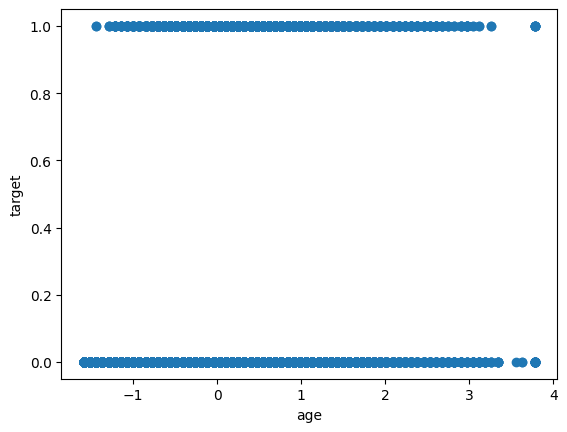

['age', 'hours-per-week']

In [18]:
# Aufteilen in train/test Set zuerst
census["target"] = census["target"].replace({" >50K": 1, " <=50K": 0})

X_train, X_test, y_train, y_test = train_test_split(
    census.drop(columns=["target"], axis=1), census["target"], test_size=0.2
)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns


# Normalerweise sind nur die Trainingsdaten bekannt, wenn der Normalisierer gefittet wird

scaler = StandardScaler() # standardisieren
#scaler = MinMaxScaler() #normalisieren
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])


# Die Testdaten müssen mit demselben Normalisierer gefittet werden
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

plt.scatter(X_train["age"], y_train)
plt.xlabel("age")
plt.ylabel("target")
plt.show()

list(numeric_cols)


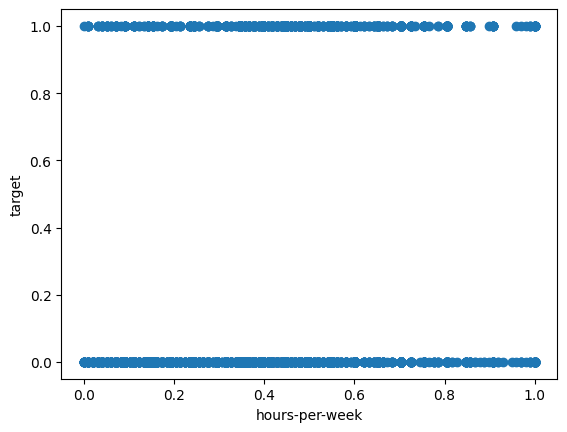

In [ ]:
# Aufteilen in train/test Set zuerst
census["target"] = census["target"].replace({" >50K": 1, " <=50K": 0})

X_train, X_test, y_train, y_test = train_test_split(
    census.drop(columns=["target"], axis=1), census["target"], test_size=0.2
)
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
list(numeric_cols)


# Normalerweise sind nur die Trainingsdaten bekannt, wenn der Normalisierer gefittet wird

#scaler = StandardScaler()  # standardisieren
scaler = MinMaxScaler() #normalisieren
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])


# Die Testdaten müssen mit demselben Normalisierer gefittet werden
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

plt.scatter(X_train["hours-per-week"], y_train)
plt.xlabel("hours-per-week")
plt.ylabel("target")
plt.show()


### 2. Predict with kNN
Sagen Sie den Einkommen >=50K oder <50K mittels kNN vorher. Plotten Sie die Akkuranz in Abhängigkeit von k nearest Neighbours. Bei längerer Rechenzeit (bei viele Iterationen) ist Prozessbar (trange (from tqdm.notebook import trange, tqdm) statt range) zu empfehlen. 

C:\Users\fried\AppData\Local\Temp\ipykernel_24048\2168852007.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  census["target"] = census["target"].replace({" >50K": 1, " <=50K": 0})


  0%|          | 0/29 [00:00<?, ?it/s]

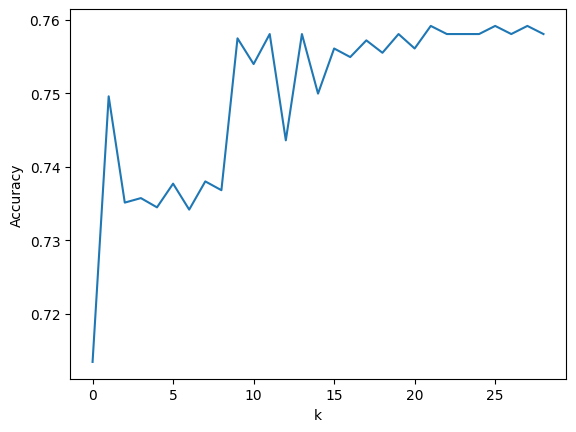

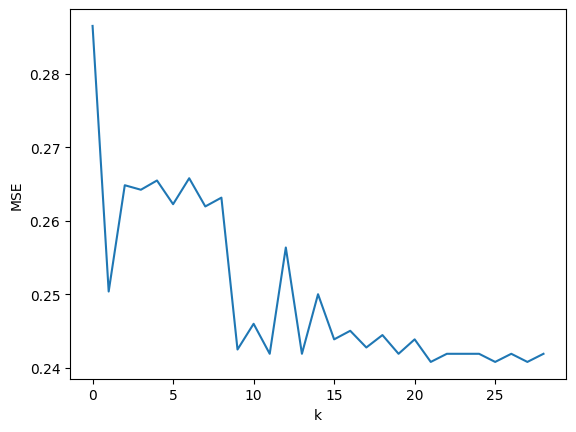

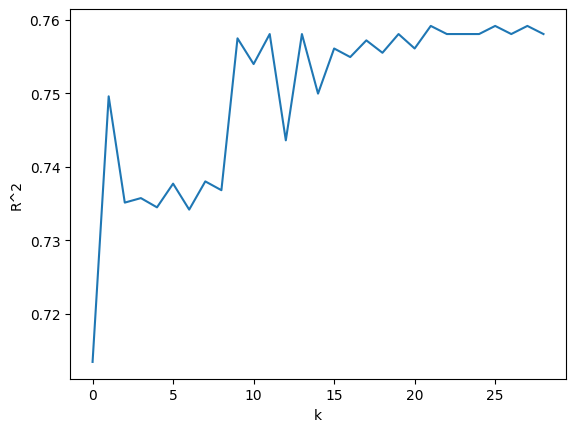

In [ ]:
path = os.path.join("..", "..", "..", "data", "census.csv")
census = pd.read_csv(path)
census = census.drop(["capital-gain", "capital-loss"], axis=1)

# Aufteilen in train/test Set zuerst
census["target"] = census["target"].replace({" >50K": 1, " <=50K": 0})

X_train, X_test, y_train, y_test = train_test_split(
    census.drop(columns=["target","education","workclass","occupation","native-country","marital-status","relationship","race","age","sex"], axis=1), census["target"], test_size=0.2
)

#print("X Train: {}".format(X_train.shape))
#print("Y Train: {}".format(y_train.shape))
#print("X Test: {}".format(X_test.shape))
#print("Y Test: {}".format(y_test.shape))

scores=[]
error=[]
accuracy=[]
# Gehe durch mögliche Nachbarwerte, trainiere das Modell und berechne die Akkuranz
#for k in trange(1, 30):


# Probiere mögliche Anzahl Nachbarn durch
for k in trange(1, 30):
    # Trainiere und evaluiere das Modell, speicher den Fehler zur Darstellung später
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    knn.score(X_test, y_test)
    error.append(mse(y_test, y_pred))
    scores.append(knn.score(X_test, y_test))
    accuracy.append(
        accuracy_score(y_pred.reshape(-1, 1), y_test.to_numpy().reshape(-1, 1))
    )

# Darstellung der Akkuranz über die gewählten Nachbarn

# plot(error)
plt.plot(accuracy)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()

plt.plot(error)
plt.xlabel("k")
plt.ylabel("MSE")
plt.show()

plt.plot(scores)
plt.xlabel("k")
plt.ylabel("R^2")
plt.show()

c:\Code-Projekte\FullStackMachineLearning\full-stack-machine-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


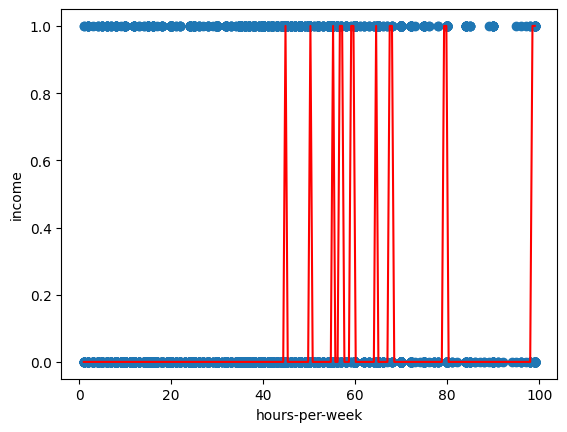

In [84]:
plt.scatter(X_train, y_train)
x_range = np.linspace(X_train.min(), X_train.max(), 200).reshape(-1, 1)
y_pred = knn.predict(x_range)

plt.plot(
    x_range,
    y_pred,
    color="red"
)
plt.xlabel("hours-per-week")
plt.ylabel("income")
plt.show()


  0%|          | 0/19 [00:00<?, ?it/s]

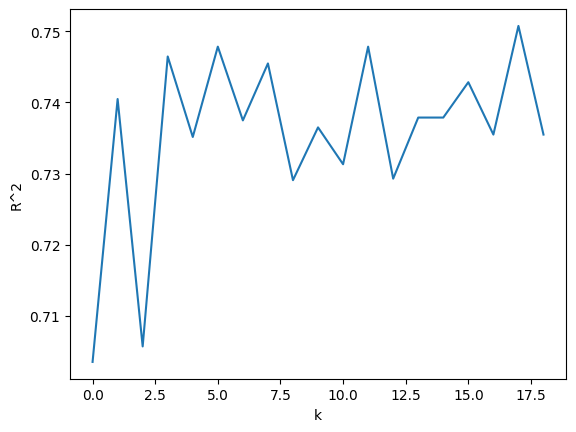

0.7354810970179049


c:\Code-Projekte\FullStackMachineLearning\full-stack-machine-learning\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


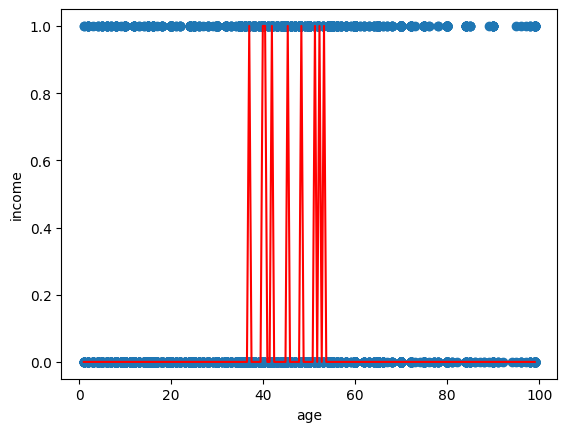

In [85]:
# Aufteilen in train/test Set zuerst
census["target"] = census["target"].replace({" >50K": 1, " <=50K": 0})

scores = []
# Gehe durch mögliche Nachbarwerte, trainiere das Modell und berechne die Akkuranz

X = census.drop(
    columns=[
        "target",
        "education",
        "workclass",
        "occupation",
        "native-country",
        "marital-status",
        "relationship",
        "race",
        "hours-per-week",
        "sex",
    ]
)
y = census["target"]

# Probiere mögliche Anzahl Nachbarn durch
for k in trange(1, 20):
    # Trainiere und evaluiere das Modell, speicher den Fehler zur Darstellung später
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)
    y_pred = knn.predict(X)
    knn.score(X, y)
    # error.append(mse(y_test, y_pred))
    scores.append(knn.score(X, y))

# Darstellung der Akkuranz über die gewählten Nachbarn
# plot(error)
plt.plot(scores)
plt.xlabel("k")
plt.ylabel("R^2")
plt.show()
print(knn.score(X, y))

#Plot Vorhersagemodell
plt.scatter(X_train, y_train)
x_range = np.linspace(X_train.min(), X_train.max(), 200).reshape(-1, 1)
y_pred = knn.predict(x_range)

plt.plot(x_range, y_pred, color="red")
plt.xlabel("age")
plt.ylabel("income")
plt.show()
